<div>

# **AI agent use Tavily**

<div dir=RTL>

# **התקנות / ספריות**

In [3]:
# התקנה
!pip install -q langgraph langchain-google-genai langchain-community tavily-python
# ספריות
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools.tavily_search import TavilySearchResults

<div dir=RTL>

# **הגדרת מודל וכלים**

In [4]:
# מפתחות
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")
# כלים
tools = [TavilySearchResults(max_results=3)]

# מודל
model = ChatGoogleGenerativeAI(
    model="gemini-pro-latest",
    google_api_key=os.environ["GOOGLE_API_KEY"]
).bind_tools(tools)

/tmp/ipykernel_2094/4221315795.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tools = [TavilySearchResults(max_results=3)]


<div dir=RTL>

# **הגדרת גרף**

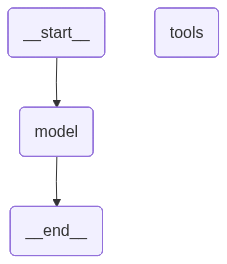

In [5]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

# צומת המודל
def call_model(state: MessagesState):
    return {"messages": [model.invoke(state["messages"])]}

# בדיקה: האם המודל ביקש להפעיל כלי?
def should_continue(state: MessagesState):
    return "tools" if state["messages"][-1].tool_calls else END

# בניית הגרף
graph = StateGraph(MessagesState)
graph.add_node("model", call_model)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "model")
graph.add_conditional_edges("model", should_continue)
graph.add_edge("tools", "model")

agent = graph.compile()

# הצגת הגרף
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

<div dir=RTL>

# **הפעלת סוכן**

In [6]:
from langchain_core.messages import HumanMessage

# שאל את הסוכן שאלה
question = "מה החדשות הכי מעניינות בתחום ה-AI היום?"
result = agent.invoke({"messages": [HumanMessage(content=question)]})

<div dir=RTL>

# **הדפסת התשובה**

In [7]:
# הדפסת תשובה
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'הנה החדשות המעניינות והבולטות ביותר בתחום ה-AI מהימים האחרונים (נכון לאפריל 2026):\n\n**1. OpenAI משיקה את GPT-5.5 - צעד משמעותי לעבר "אפליקציית-על" (Super App)**\nOpenAI שחררה את המודל החדש שלה, GPT-5.5. המודל מציג ביצועים חסרי תקדים בתחומים של "פעולה סוכנותית" (Agentic behavior) - כלומר, היכולת שלו להפעיל סביבות מחשב באופן עצמאי, לכתוב קוד מורכב ולבצע עבודות מחקר מדעיות ורפואיות (כמו גילוי תרופות). למרות שהוא חכם משמעותית מ-GPT-5.4, הוא שומר על אותה מהירות תגובה. בנוסף, הוא שבר שיאים במבדקי סייבר ממשלתיים (UK AISI), והראה יכולת לנהל קמפיינים אוטומטיים שלמים של חקר חולשות אבטחה במשך ימים ברציפות.\n\n**2. אנתרופיק (Anthropic) מציגה "כלכלת סוכנים" - מודלי AI שסוחרים זה עם זה**\nבניסוי פנימי מרתק שנקרא "Project Deal", חברת Anthropic נתנה ל-69 עובדים תקציב של 100 דולר וביקשה מהם להגדיר מה הם רוצים לקנות או למכור, ומה סגנון המשא ומתן המועדף עליהם. מכאן והלאה, סוכני AI (מבוססי Claude) ניהלו את כל המשא ומתן אחד מול השני דרך סלאק (Slack). הסוכנים סגרו בהצלחה 186 עסק